# Runtime figures

Data: `results/tested/`. Run cells in order from the `AnDri_tmp` folder.


In [79]:
########### 2026-10-09 ################
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_df = pd.read_csv('results/tested/runtime_graph.csv', float_precision='round_trip')
datasets = ('climate', 'traffic', 'nab', 'ucr_environment', 'smd', 'catsv2')
method_order = ('andri_off', 'cabd', 'norma', 'andri_on', 'sand',
                'tranad', 'arcus', 'divad', 'meter', 'candi')
method_names = {
    'andri_off': 'AnDri-offline', 'cabd': 'CABD', 'norma': 'NormA',
    'andri_on': 'AnDri', 'sand': 'SAND', 'tranad': 'TranAD',
    'arcus': 'ARCUS', 'divad': 'DIVAD', 'meter': 'METER', 'candi': 'CANDI'
}
colors = ('#74BDE4', '#E474C6', '#F7AE75', '#6EDA94', '#F38597',
          '#EEE68A', '#8AA8EE', '#B48AEE', '#8AEBEE', '#E6B77A')
hatches = ('//', 'xx', '\\', '--', '...', '**', 'OO', '++', '..', 'oo')
method_colors = dict(zip(method_order, colors))
method_hatches = dict(zip(method_order, hatches))


## Runtime 1×2 — Offline / Online


/home/parkj182/tmp/ipykernel_187283/3196977687.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_runtime_1x2.tight_layout(rect=(0, 0, 1, 0.91))


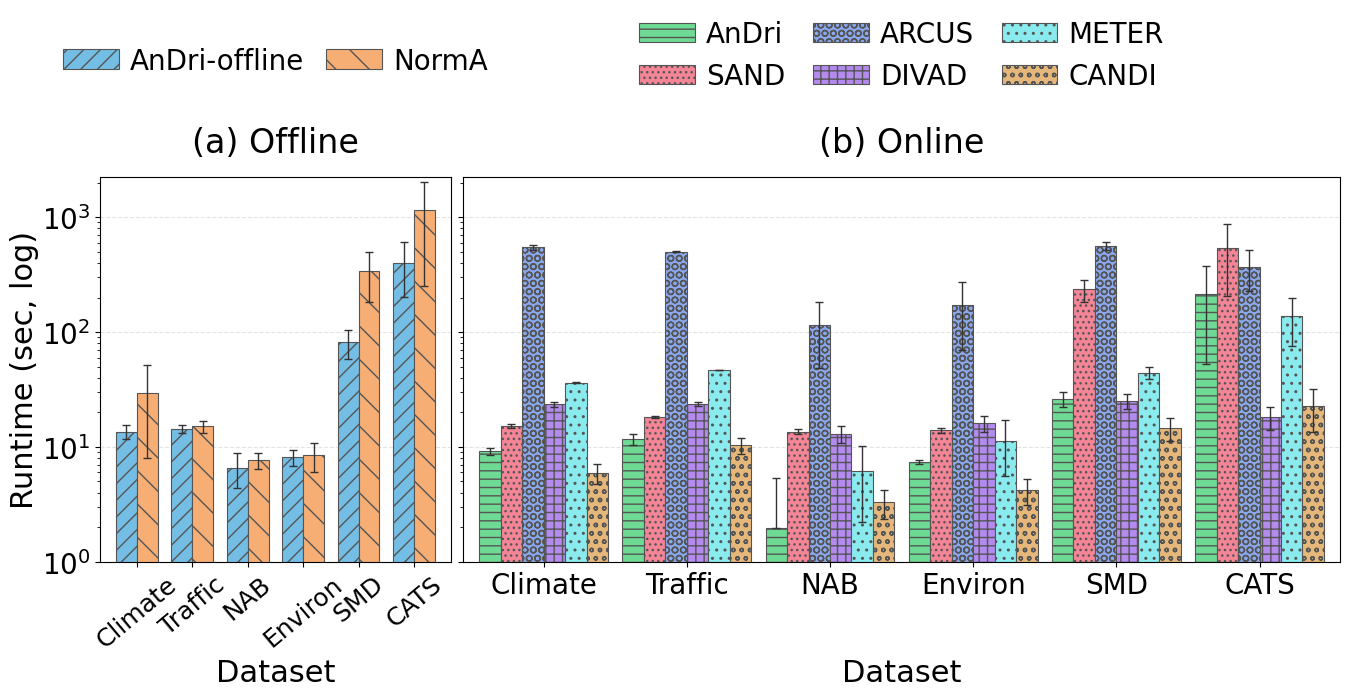

In [80]:
########### 2026-10-09 ################
# Split the preceding runtime graph into Offline and Online columns, excluding CABD and TranAD.
import matplotlib.pyplot as plt
import numpy as np


offline_methods = tuple(method for method in method_order[:3] if method != 'cabd')
online_methods = tuple(method for method in method_order[3:] if method != 'tranad')

column_methods = (offline_methods, online_methods)
dataset_labels = ('Climate', 'Traffic', 'NAB', 'Environ', 'SMD', 'CATS')
x_1x2 = np.arange(len(datasets))* 0.8
bar_widths_1x2 = (0.3, 0.12)
panel_df = plot_df.loc[plot_df.method.isin(offline_methods + online_methods)]
y_limits = (
    1,
    (panel_df.mean_seconds + panel_df.std_seconds).max() * 1.1,
)

with plt.rc_context({'font.size': 20}):
    fig_runtime_1x2, axes_runtime_1x2 = plt.subplots(
        1, 2, figsize=(16, 5), sharey=True,
        gridspec_kw={'width_ratios': [2, 5], 'wspace': 0.02},
    )

    for col, methods_in_panel in enumerate(column_methods):
        ax = axes_runtime_1x2[col]
        width = bar_widths_1x2[col]
        center = (len(methods_in_panel) - 1) / 2
        for method_index, method in enumerate(methods_in_panel):
            subset = (plot_df.loc[plot_df.method.eq(method)]
                      .set_index('dataset').loc[list(datasets)])
            means = subset.mean_seconds.to_numpy(dtype=float)
            stds = subset.std_seconds.to_numpy(dtype=float)
            positions = x_1x2 + (method_index - center) * width

            ax.bar(
                positions, means, width,
                color=method_colors[method], edgecolor='#555555', linewidth=0.8,
                hatch=method_hatches[method], label=method_names[method],
            )
            valid = np.isfinite(means) & np.isfinite(stds)
            lower = np.where(means[valid] > stds[valid], stds[valid], 0.0)
            ax.errorbar(
                positions[valid], means[valid],
                yerr=np.vstack((lower, stds[valid])), fmt='none',
                ecolor='#333333', elinewidth=1.0, capthick=1.0,
                capsize=3, zorder=5,
            )

        ax.set_yscale('log')
        ax.set_ylim(*y_limits)
        ax.set_xticks(x_1x2)
        ax.tick_params(axis='both', labelsize=20)
        if col ==0:
            ax.set_xticklabels(dataset_labels, fontsize=18, rotation=40)
        else:
            ax.set_xticklabels(dataset_labels, fontsize=20, rotation=0)
        ax.set_xlabel('Dataset', fontsize=22)
        ax.xaxis.set_label_coords(0.5, -0.25)
        ax.grid(axis='y', linestyle='--', alpha=0.35)
        
        ax.set_axisbelow(True)
        if col == 1:
            ax.set_xlim(x_1x2[0] - 0.45, x_1x2[-1] + 0.45)

    axes_runtime_1x2[0].set_title('(a) Offline', fontsize=24, pad=18)
    axes_runtime_1x2[1].set_title('(b) Online', fontsize=24, pad=18)
    axes_runtime_1x2[0].set_ylabel('Runtime (sec, log)', fontsize=22, labelpad=2)
    axes_runtime_1x2[1].tick_params(axis='y', labelleft=False)

    axes_runtime_1x2[0].legend(
        loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=2,
        frameon=False, fontsize=20, columnspacing=0.8, handletextpad=0.4,
    )
    axes_runtime_1x2[1].legend(
        loc='lower center', bbox_to_anchor=(0.5, 1.16), ncol=3,
        frameon=False, fontsize=20, columnspacing=1.0, handletextpad=0.4,
    )

    fig_runtime_1x2.tight_layout(rect=(0, 0, 1, 0.91))
    plt.show()


## Breakdown


,normal_model_learning_s,normal_model_mgmt_enqueue_s,anomaly_scoring_s,scored_features
dataset,,,,
climate,5.540983,54.534606,39.924411,30
traffic,1.681277,74.098945,24.219779,30
nab,2.368465,60.092932,37.538603,11
ucr_environment,2.103902,62.468118,35.427980,16
smd,5.889943,49.358374,44.751682,429
catsv2,0.489665,76.245900,23.264435,59


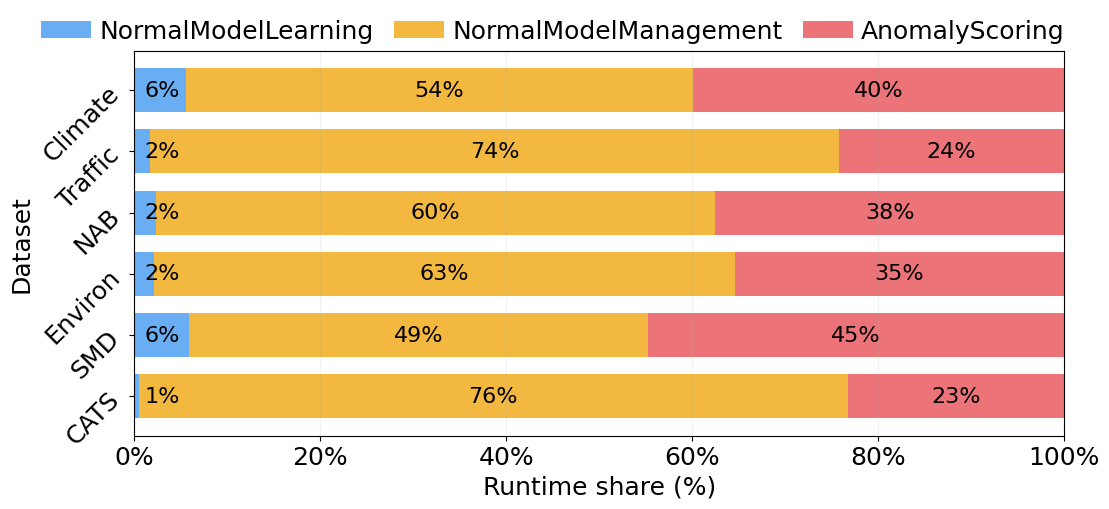

In [81]:
########### 2026-10-09 ################
# AnDri-on: 점수가 생성된 feature의 세 구간 실행 시간 점유율
breakdown_path = Path('results/tested/runtime_break_down.csv')
breakdown = pd.read_csv(breakdown_path, float_precision='round_trip')
breakdown_ok = breakdown.loc[breakdown.status.eq('ok')].copy()
breakdown_ok['dataset'] = breakdown_ok.dataset.replace({'ucr': 'ucr_environment', 'CATSv2': 'catsv2'})
components = {'normal_model_learning_s': 'NormalModelLearning',
              'normal_model_mgmt_enqueue_s': 'NormalModelManagement',
              'anomaly_scoring_s': 'AnomalyScoring'}
breakdown_totals = breakdown_ok.groupby('dataset')[list(components)].sum().loc[list(datasets)]
breakdown_share = breakdown_totals.div(breakdown_totals.sum(axis=1), axis=0) * 100
breakdown_counts = breakdown_ok.groupby('dataset').size().loc[list(datasets)]
# Display integers with the largest-remainder rule so each row reads exactly 100%.
fractions = breakdown_share.to_numpy()
rounded = np.floor(fractions).astype(int)
for row in range(len(datasets)):
    remaining = 100 - rounded[row].sum()
    rounded[row, np.argsort(-(fractions[row] - rounded[row]))[:remaining]] += 1
display_share = pd.DataFrame(rounded, index=breakdown_share.index, columns=breakdown_share.columns)

plt.rcParams.update({'font.size': 18})
fig_breakdown, ax_breakdown = plt.subplots(figsize=(12, 5))
y = np.arange(len(datasets))
left = np.zeros(len(datasets))
for color, (column, label) in zip(('#69AEF2', '#F3B83F', '#EC7478'), components.items()):
    values = breakdown_share[column].to_numpy()
    ax_breakdown.barh(y, values, left=left, height=0.72, color=color, label=label)
    for position, start, value, shown in zip(y, left, values, display_share[column]):
        label_x = max(start + value / 2, 3) if column == 'normal_model_learning_s' else start + value / 2
        ax_breakdown.text(label_x, position, f'{shown}%',
                          ha='center', va='center', fontsize=16)
    left += values
ax_breakdown.set_yticks(y, ['Climate', 'Traffic', 'NAB', 'Environ', 'SMD', 'CATS'])
ax_breakdown.tick_params(axis='y', labelrotation=45)
ax_breakdown.invert_yaxis()
ax_breakdown.set_xlim(0, 100)
ax_breakdown.set_xticks(np.arange(0, 101, 20), [f'{value}%' for value in range(0, 101, 20)], fontsize=18)
ax_breakdown.set_xlabel('Runtime share (%)', fontsize=18)
ax_breakdown.set_ylabel('Dataset', fontsize=18)
ax_breakdown.legend(loc='upper center', bbox_to_anchor=(0.45, 1.14), ncol=3, frameon=False, fontsize=18, columnspacing=0.8, handletextpad=0.35)
ax_breakdown.grid(axis='x', alpha=0.18)
# ax_breakdown.set_axisbelow(True)
# fig_breakdown.text(0.5, 0.015, 'Share of the three measured components; online_other is excluded.',
                #    ha='center', fontsize=11)
# fig_breakdown.tight_layout(rect=(0, 0.06, 1, 0.89))
display(breakdown_share.assign(scored_features=breakdown_counts))
# plt.show()
plt.show()


## Rollback 1×3 — Climate, NAB, Environ


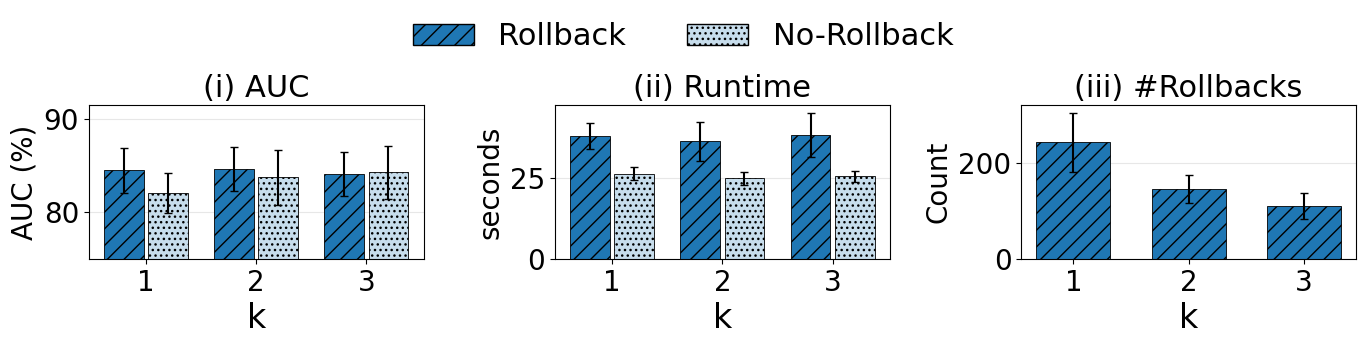

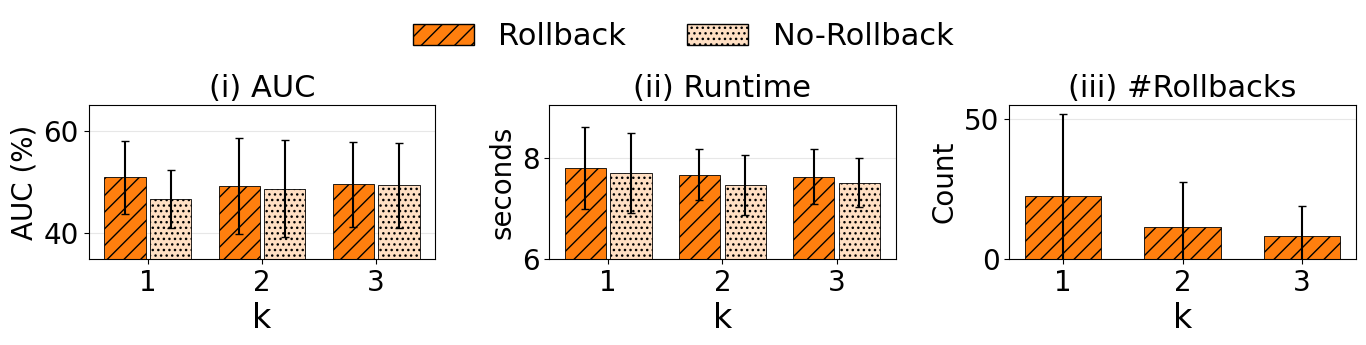

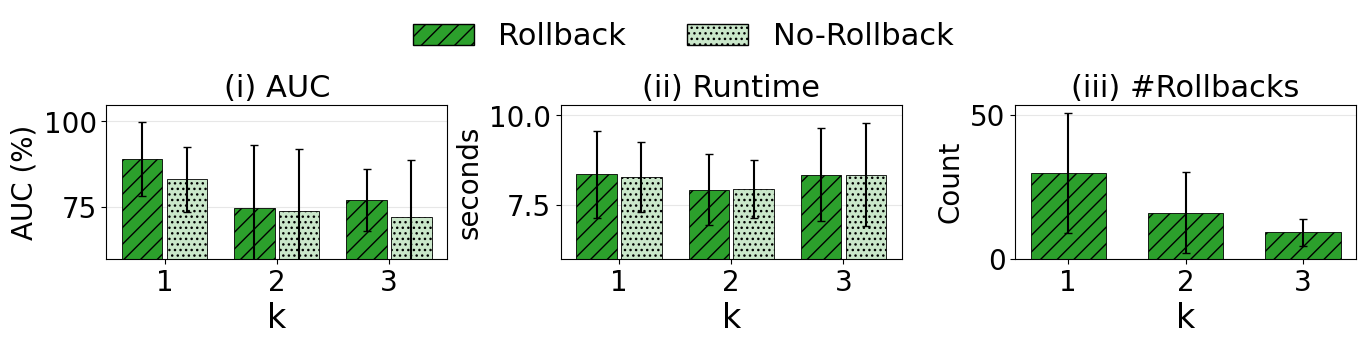

In [82]:
########### 2026-10-09 ################
selected_df_climate = pd.read_csv('results/tested/selected_df_climate.csv', float_precision='round_trip')
selected_df_nab = pd.read_csv('results/tested/selected_df_nab.csv', float_precision='round_trip')
selected_df_ucr = pd.read_csv('results/tested/selected_df_ucr.csv', float_precision='round_trip')

# Climate, NAB, Environ을 각각 1×3 그림으로 그립니다.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch

plot_datasets_1x3 = [
    ('Climate', selected_df_climate, 'tab:blue'),
    ('NAB', selected_df_nab, 'tab:orange'),
    ('Environ', selected_df_ucr, 'tab:green'),
]
for name, df, color in plot_datasets_1x3:
    k_values = sorted(df.k.unique())
    x = np.arange(len(k_values)) * 0.5
    off_color = tuple(0.25 * np.array(to_rgb(color)) + 0.75 * np.ones(3))
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

    for ax, metric in zip(axes[:2], ('AUC', 'runtime_seconds')):
        for rollback, shift, facecolor, hatch in (
            (True, -0.10, color, '//'),
            (False, 0.10, off_color, '...'),
        ):
            summary = (df.loc[df.rollback.eq(rollback)]
                       .groupby('k')[metric].agg(['mean', 'std']).reindex(k_values))
            scale = 100 if metric == 'AUC' else 1
            ax.bar(x + shift, summary['mean'] * scale, width=0.18,
                   yerr=summary['std'].fillna(0) * scale, capsize=3,
                   color=facecolor, edgecolor='black', linewidth=0.6, hatch=hatch)
            # print(metric, rollback)
            # display(summary)

    # #Rollback은 rollback=True의 num_flip만 표시합니다.
    flips = (df.loc[df.rollback]
             .groupby('k').num_flip.agg(['mean', 'std']).reindex(k_values))
    axes[2].bar(x, flips['mean'], width=0.32,
                yerr=flips['std'].fillna(0), capsize=3,
                color=color, edgecolor='black', linewidth=0.6, hatch='//')

    # 기존 3×3 셀의 dataset별 y 범위를 유지합니다. AUC는 % 단위로 환산합니다.
    if name == 'Climate':
        axes[0].set_ylim(bottom=75)
    elif name == 'NAB':
        axes[0].set_ylim(35, 65)
        axes[1].set_ylim(bottom=6)
    else:
        axes[0].set_ylim(bottom=60)
        axes[1].set_ylim(bottom=6)
    axes[2].set_ylim(bottom=0)

    for ax, title, ylabel in zip(axes,
                                  ('(i) AUC', '(ii) Runtime', '(iii) #Rollbacks'),
                                  ('AUC (%)', 'seconds', 'Count')):
        ax.set_title(title, fontsize=22)
        ax.set_ylabel(ylabel, fontsize=20)
        ax.set_xticks(x, k_values)
        ax.set_xlabel('k', fontsize=24)
        ax.tick_params(axis='both', labelsize=20)
        ax.grid(axis='y', alpha=0.3)
        ax.set_axisbelow(True)

    legend_handles = [
        Patch(facecolor=color, edgecolor='black', hatch='//', label='Rollback'),
        Patch(facecolor=off_color, edgecolor='black', hatch='...', label='No-Rollback'),
    ]
    # fig.suptitle(name, fontsize=22, y=1.16)
    fig.legend(handles=legend_handles, ncol=2, loc='upper center',
               bbox_to_anchor=(0.5, 1.05), fontsize=22, frameon=False)
    fig.tight_layout(w_pad=1.4, rect=(0, 0, 1, 0.90))
    plt.show()


## TPR / FPR bargraph v2 — Offline / Online 2×2


/home/parkj182/tmp/ipykernel_187283/3681681675.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.91))


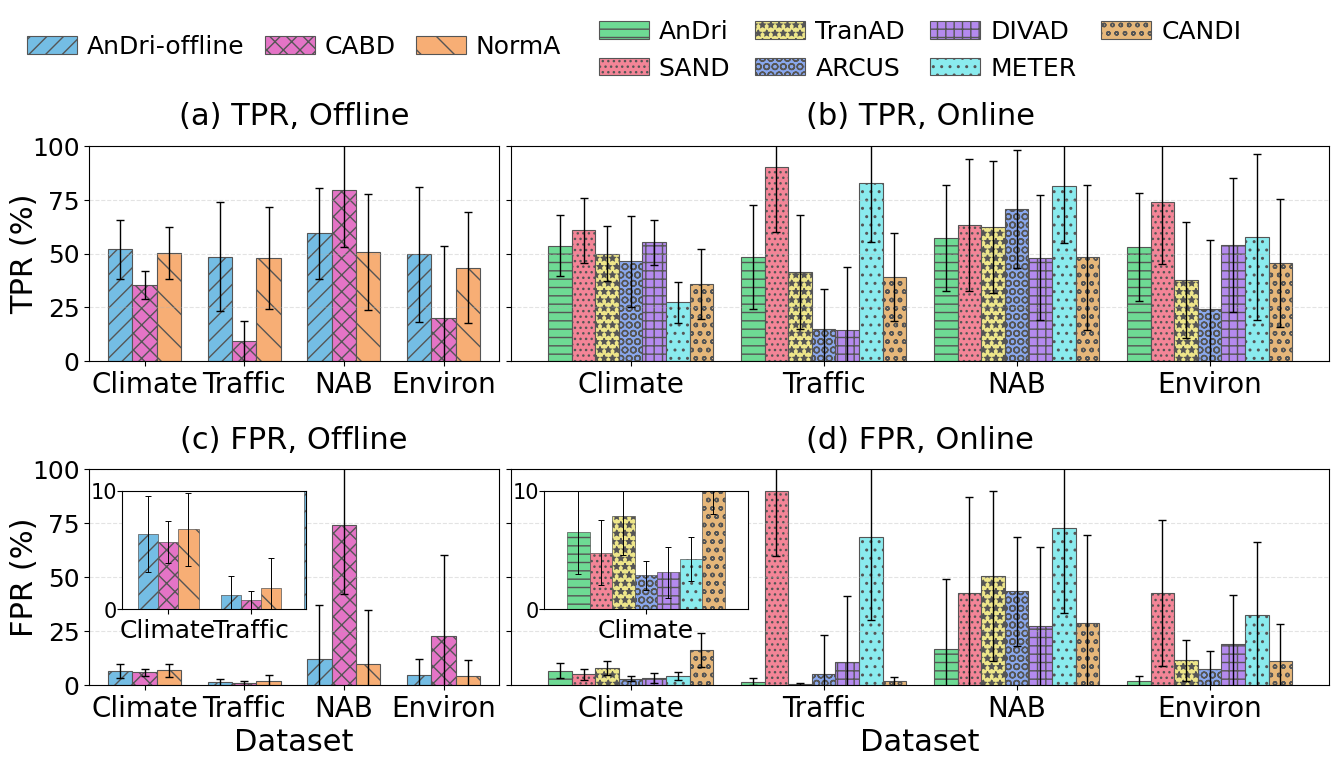

In [83]:
########### 2026-10-09 ################
# TPR/FPR rows and Offline/Online columns; keep v2 colors and hatches.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

colors = ("#74BDE4", "#E474C6", "#F7AE75", "#6EDA94", "#F38597",
          "#EEE68A", "#8AA8EE", "#B48AEE", "#8AEBEE", "#E6B77A")
hatches = ('//', 'xx', '\\', '--', '...', '**', 'OO', '++', '..', 'oo')

metric_plot_methods = [
    'AnDri (off)', 'CABD', 'NormA', 'AnDri (on)', 'SAND',
    'TranAD', 'ARCUS', 'DIVAD', 'METER', 'CANDI'
]
metric_plot_names = {
    'AnDri (off)': 'AnDri-offline', 'CABD': 'CABD', 'NormA': 'NormA',
    'AnDri (on)': 'AnDri', 'SAND': 'SAND', 'TranAD': 'TranAD',
    'ARCUS': 'ARCUS', 'DIVAD': 'DIVAD', 'METER': 'METER', 'CANDI': 'CANDI'
}
metric_plot_datasets = {
    'Climate': 'climate',
    'Traffic': 'traffic',
    'NAB': 'nab',
    'Environ': 'ucr_environment',
}
offline_methods = metric_plot_methods[:3]
online_methods = metric_plot_methods[3:]
method_colors = dict(zip(metric_plot_methods, colors))
method_hatches = dict(zip(metric_plot_methods, hatches))

########### 2026-10-09 ################
metric_plot_df = pd.read_csv('results/tested/metric_plot_method.csv', float_precision='round_trip')
summary_by_dataset = {}
for dataset_name, file_stem in metric_plot_datasets.items():
    summary = (metric_plot_df.loc[metric_plot_df.dataset.eq(file_stem)]
               .set_index('method').reindex(metric_plot_methods))
    required = ['TPR_mean', 'TPR_variance', 'FPR_mean', 'FPR_variance']
    if summary[required].isna().all(axis=1).any():
        missing = summary.index[summary[['TPR_mean', 'FPR_mean']].isna().all(axis=1)].tolist()
        raise ValueError(f'Missing method results for {dataset_name}: {missing}')
    summary_by_dataset[dataset_name] = summary


def metric_mean_std(method, metric):
    means = np.array([
        summary_by_dataset[dataset].loc[method, f'{metric}_mean']
        for dataset in metric_plot_datasets
    ], dtype=float)
    stds = np.sqrt(np.array([
        summary_by_dataset[dataset].loc[method, f'{metric}_variance']
        for dataset in metric_plot_datasets
    ], dtype=float))

    # Preserve the display adjustments used in the existing v2 cell.
    if method == 'NormA' and metric == 'TPR':
        means[0] -= 0.03
        means[1] -= 0.03
    if method == 'AnDri (on)' and metric == 'TPR':
        means[0] += 0.02
        means[1] += 0.02
    return means * 100, stds * 100


x = np.arange(len(metric_plot_datasets))*0.9
column_methods = (offline_methods, online_methods)
bar_widths = (0.22, 0.11)

with plt.rc_context({'font.size': 20}):
    fig, axes = plt.subplots(
        2, 2, figsize=(16, 7), sharex='col', sharey='row',
        gridspec_kw={'width_ratios': [1, 2], 'wspace': 0.02, 'hspace': 0.50},
    )

    for row, metric in enumerate(('TPR', 'FPR')):
        for col, methods_in_panel in enumerate(column_methods):
            ax = axes[row, col]
            width = bar_widths[col]
            center = (len(methods_in_panel) - 1) / 2
            for method_index, method in enumerate(methods_in_panel):
                means, stds = metric_mean_std(method, metric)
                positions = x + (method_index - center) * width
                ax.bar(
                    positions, means, width, yerr=stds,
                    color=method_colors[method], edgecolor='#555555', linewidth=0.8,
                    hatch=method_hatches[method], capsize=3,
                    label=metric_plot_names[method],
                    error_kw={'elinewidth': 1.0, 'capthick': 1.0},
                )
            
            ax.set_ylim(0, 100)
            ax.grid(axis='y', linestyle='--', alpha=0.35)
            ax.tick_params(axis='both', labelsize=18)

    axes[0, 0].set_title('(a) TPR, Offline', fontsize=22, pad=15)
    axes[0, 1].set_title('(b) TPR, Online', fontsize=22, pad=15)
    axes[1, 0].set_title('(c) FPR, Offline', fontsize=22, pad=15)
    axes[1, 1].set_title('(d) FPR, Online', fontsize=22, pad=15)
    axes[0, 0].set_ylabel('TPR (%)', fontsize=22, labelpad=-5)
    axes[1, 0].set_ylabel('FPR (%)', fontsize=22, labelpad=-5)

    # Show dataset ticks and x labels on all four panels.
    for i, ax in enumerate(axes.flat):
        ax.set_xticks(x)
        ax.set_xticklabels(metric_plot_datasets, fontsize=20)
        ax.tick_params(axis='x', labelbottom=True)
        if i >1:
            ax.set_xlabel('Dataset', fontsize=22)

    # Enlarge the low FPR range without hiding values above 10% in the main panels.
    for col, methods_in_panel in enumerate(column_methods):
        if col == 0:
            zoom_ax = axes[1, col].inset_axes((0.08, 0.35, 0.45, 0.55))
        if col == 1:
            zoom_ax = axes[1, col].inset_axes((0.04, 0.35, 0.25, 0.55))
        width = bar_widths[col]
        center = (len(methods_in_panel) - 1) / 2
        for method_index, method in enumerate(methods_in_panel):
            means, stds = metric_mean_std(method, 'FPR')
            positions = x + (method_index - center) * width
            zoom_ax.bar(
                positions, means, width, yerr=stds,
                color=method_colors[method], edgecolor='#555555', linewidth=0.5,
                hatch=method_hatches[method], capsize=2,
                error_kw={'elinewidth': 0.7, 'capthick': 0.7},
            )
        zoom_ax.set_xlim(-0.5, 1.5 if col == 0 else 0.5)
        zoom_ax.set_ylim(0, 10)
        zoom_ax.set_yticks((0, 10))
        if col ==0:
            zoom_ax.set_xticks(x[:2], list(metric_plot_datasets)[:2], fontsize=18)
        else:
            zoom_ax.set_xticks(x[:1], list(metric_plot_datasets)[:1], fontsize=18)
        zoom_ax.tick_params(axis='y', labelsize=15, pad =0)
        zoom_ax.set_facecolor('white')
        zoom_ax.patch.set_alpha(1)

    # Each column has its own method legend.
    axes[0, 0].legend(
        loc='lower center', bbox_to_anchor=(0.5, 1.3), ncol=3,
        frameon=False, fontsize=18, columnspacing=0.8, handletextpad=0.4,
    )
    axes[0, 1].legend(
        loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=4,
        frameon=False, fontsize=18, columnspacing=1, handletextpad=0.4,
    )

    fig.tight_layout(rect=(0, 0, 1, 0.91))
    plt.show()


# KDE figures

Run the setup cell, then the KDE and cluster cells for each dataset. Inputs are in `results/tested/kde_*`.

In [84]:
from pathlib import Path
from types import SimpleNamespace
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.lines import Line2D
from sklearn.preprocessing import MinMaxScaler

Path('png').mkdir(exist_ok=True)
METHODS = ['AnDri (off)', 'CABD', 'NormA', 'AnDri (on)', 'SAND',
           'TranAD', 'ARCUS', 'DIVAD', 'METER', 'CANDI']
NAMES = ['AnDri-offline', 'CABD', 'NormA', 'AnDri', 'SAND',
         'TranAD', 'ARCUS', 'DIVAD', 'METER', 'CANDI']

def saved_plot(dataset):
    folder = Path('results/tested') / f'kde_{dataset}'
    score_df = pd.read_csv(folder / 'scores.csv', float_precision='round_trip')
    model = SimpleNamespace(
        cl_s=pd.read_csv(folder / 'clusters.csv').cluster.to_numpy(),
        NMs=[SimpleNamespace(subseq=row) for row in
             pd.read_csv(folder / 'subseqs.csv', header=None, float_precision='round_trip').to_numpy()])
    scores = [MinMaxScaler().fit_transform(score_df[[method]]).ravel() for method in METHODS]
    labels = score_df.label.to_numpy(dtype=int)
    clusters = np.asarray(model.cl_s)[score_df.position.to_numpy(dtype=int)]
    timestamps = (pd.to_datetime(pd.read_csv(folder / 'timestamps.csv').timestamp).to_numpy()
                  if dataset != 'nab' else None)
    return scores, labels, clusters, model, timestamps

def draw_kde_sub(ax, cl_s, label, scores, max_y=4, sel_cl=7):
    cluster_adj = cl_s.astype(object)
    cluster_adj[label == 1] = 'Anomaly'
    
    min_len = min(len(scores), len(cluster_adj))
    scores = scores[:min_len]
    cluster_adj = cluster_adj[:min_len]

    df_plot = pd.DataFrame({'score': scores + 1e-6, 'cluster': cluster_adj})    ## for log-scale computation, add a small value to avoid log(0)
    
    clusters = sorted([c for c in df_plot['cluster'].unique() if c != 'Anomaly'], key=lambda x: int(x))
    hue_order = clusters + ['Anomaly']
    
    normal_ids = [int(c) for c in np.unique(cl_s) if c >= 0]
    colors = [color for i, color in enumerate(sns.color_palette('tab20', max(normal_ids, default=-1) + 3)) if i not in (6, 7)]
    palette = {c: colors[int(c)] for c in clusters if c >= 0}
    if -1 in clusters:
        palette[-1] = '0.5'
    if sel_cl in palette:
        palette[sel_cl] = 'blue'
    palette['Anomaly'] = 'red'

    sns.kdeplot(
        data=df_plot, x='score', hue='cluster', hue_order=hue_order,
        palette=palette, fill=True, alpha=0.2, linewidth=1.5,
        common_norm=False, log_scale=True, legend=False, ax=ax
    )

    if sel_cl in df_plot['cluster'].values:
        sns.kdeplot(
            data=df_plot[df_plot['cluster'] == sel_cl],
            x='score', color='blue', fill=True,
            alpha=0.3, linewidth=1.5,
            common_norm=False, log_scale=True,
            legend=False, zorder=9, ax=ax
        )

    sns.kdeplot(
        data=df_plot[df_plot['cluster'] == 'Anomaly'],
        x='score', color=palette['Anomaly'], fill=True,
        alpha=0.4, linewidth=2.5, log_scale=True, zorder=10, ax=ax
    )
    
    ax.set_xlim(1e-7, 10)
    ax.set_ylim(0, max_y)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=10))
    ax.set_xlabel('') # to split offline / online
    ax.set_ylabel('')
    
    handles = [
        Line2D(
            [0], [0],
            color=palette[c],
            lw=3,
            linestyle='-'
        )
        for c in hue_order
    ]
    labels = ['Anomaly' if c == 'Anomaly' else 'Unassigned' if c == -1 else f'CL {int(c)}' for c in hue_order]
    
    return handles, labels

def draw_kde(methods, off_cls, scores, label, y_max=None, sel_cl=7, fname=None, dataset=None):
    if len(methods) != len(scores):
        raise ValueError('method 이름과 score 개수가 다릅니다.')
    if len(methods) == 10:
        rows, columns = 2, 5
    else:
        columns = 4 if len(methods) <= 8 else 5
        rows = math.ceil(len(methods) / columns)
    roman = ('i', 'ii', 'iii', 'iv', 'v', 'vi', 'vii', 'viii', 'ix', 'x')
    if len(methods) > len(roman):
        raise ValueError(f'Roman subplot labels support at most {len(roman)} methods')
    subs = [f'({roman[i]})' for i in range(len(methods))]
    fig, axes = plt.subplots(rows, columns, figsize=(4.5*columns, 2*rows),
                             sharex=True, sharey=True, squeeze=False)
    axes = axes.flatten()
    for ax in axes[len(methods):]:
        ax.set_visible(False)

    all_handles, all_labels = [], []
    cl_s = off_cls.cl_s
    cl_s = cl_s[:len(label)]

    is_climate = dataset == 'climate' or (
        fname is not None and 'climate' in str(fname).lower()
    )
    y_lim_high = 5 if is_climate else 4

    for i, scores in enumerate(scores): 
        if y_max is not None:
            is_andri = methods[i] in ('AnDri-offline', 'AnDri', 'AnDri (off)', 'AnDri (on)')
            max_y = y_max if is_andri else y_lim_high
        else:
            max_y=1
        print(i, max_y)
        h, l = draw_kde_sub(axes[i], cl_s, label, scores, max_y=max_y, sel_cl=sel_cl)
        if i == 0: 
            all_handles, all_labels = h, l
        title_x = 0.42
        if is_climate:
            if methods[i] in ('NormA', 'SAND'):
                title_x = 0.25
            elif methods[i] in ('DIVAD'):
                title_x = 0.70
            elif methods[i] in ['TranAD', 'CABD', 'METER', 'CANDI']:
                title_x = 0.5
        axes[i].set_title(
            f'{subs[i]}  {methods[i]}', fontsize=18,
            x=title_x, y=0.88, ha='center', va='top', pad=0,
        )

    plt.tight_layout(rect=[0, 0.03, 0.84, 1])
    plt.subplots_adjust(hspace=0.28)

    fig.legend(
        all_handles,
        all_labels,
        loc='center left',
        bbox_to_anchor=(0.84, 0.5),
        ncol=2,
        frameon=False,
        fontsize=18,
        handlelength=0.9,
        handletextpad=0.5,
        columnspacing=0.6,
        labelspacing=0.5,
        borderaxespad=0.2,
    )
    if 'nab' in fname:
        fig.supxlabel('Normalized Anomaly Score (log)', fontsize=20)
    fig.supylabel('Probability Density', x=-0.02)
    
    if fname is not None:
        plt.savefig(f'png/kde_{fname}.pdf', bbox_inches="tight")
    plt.show()


## Traffic KDE graph - Table Read

62783 common timestamps
0 1.5
1 4
2 4
3 1.5
4 4
5 4
6 4
7 4


/home/parkj182/tmp/ipykernel_187283/489636846.py:54: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/home/parkj182/tmp/ipykernel_187283/489636846.py:61: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


8 4
9 4


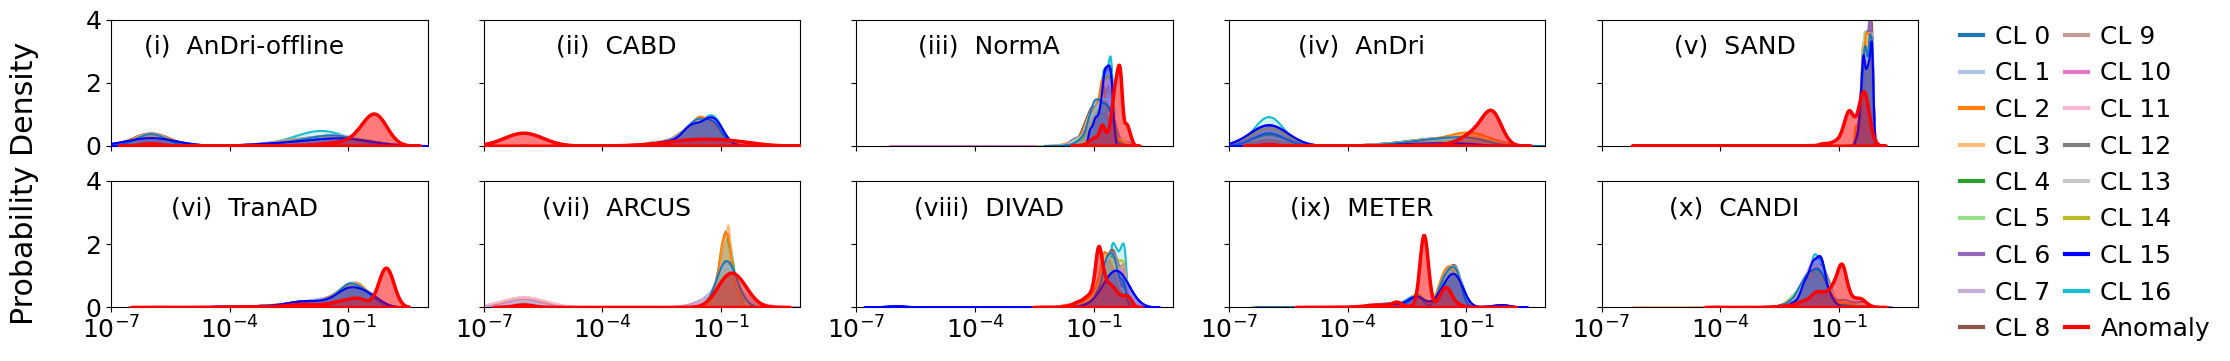

In [85]:
traffic_plot_station = '400598'
sel_cl = 15
traffic_plot_scores, traffic_plot_labels, traffic_plot_clusters, traffic_table_model, traffic_timestamps = saved_plot('traffic')
traffic_table_df = pd.DataFrame({'timestamp': pd.to_datetime(traffic_timestamps)})
print(len(traffic_plot_labels), 'common timestamps')
draw_kde(NAMES, SimpleNamespace(cl_s=traffic_plot_clusters), traffic_plot_scores,
         traffic_plot_labels, y_max=1.5, sel_cl=sel_cl,
         fname=f'traffic_{traffic_plot_station}')

## Cluster distribution (traffic - Table Read)

/home/parkj182/tmp/ipykernel_187283/2648352000.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_yticklabels([ '', 25, 50, 75, 100])
/home/parkj182/tmp/ipykernel_187283/2648352000.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(['0', '2k', '4k', '6k'], fontsize=18)


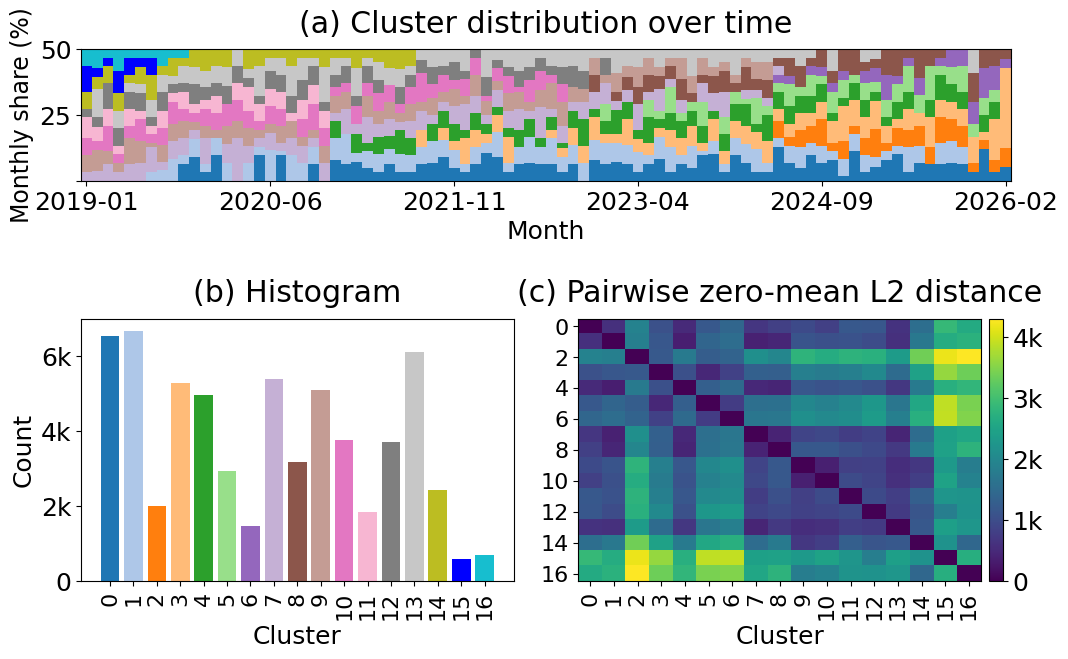

In [86]:
from scipy.spatial.distance import pdist, squareform

model = traffic_table_model
n = min(len(model.cl_s), len(traffic_table_df))
assignments = np.asarray(model.cl_s[:n], dtype=int)
months = pd.to_datetime(traffic_table_df['timestamp'].iloc[:n]).dt.to_period('M').dt.to_timestamp()
cluster_ids = sorted(np.unique(assignments))
normal_ids = [cluster_id for cluster_id in cluster_ids if cluster_id != -1]
colors = [color for i, color in enumerate(sns.color_palette('tab20', max(normal_ids, default=-1) + 3)) if i not in (6, 7)]
cluster_colors = {cluster_id: colors[int(cluster_id)] for cluster_id in normal_ids}
if sel_cl in cluster_colors:
    cluster_colors[sel_cl] = 'blue'
if -1 in cluster_ids:
    cluster_colors[-1] = '0.5'

monthly_counts = pd.crosstab(months, assignments).reindex(columns=cluster_ids, fill_value=0)
monthly_share = monthly_counts.div(monthly_counts.sum(axis=1), axis=0)
positions = np.arange(len(monthly_share))

fig = plt.figure(figsize=(12, 7))
grid = fig.add_gridspec(2, 2, height_ratios=[1, 2], hspace=0.7, wspace=0.15)
ax0 = fig.add_subplot(grid[0, :])
ax1 = fig.add_subplot(grid[1, 0])
ax2 = fig.add_subplot(grid[1, 1])

bottom = np.zeros(len(monthly_share))
for cluster_id in cluster_ids:
    share = monthly_share[cluster_id].to_numpy()
    ax0.bar(positions, share, bottom=bottom, width=1, color=cluster_colors[cluster_id])
    bottom += share
ax0.set_ylim(0, 1)
ax0.set_yticklabels([ '', 25, 50, 75, 100])
ax0.set_ylabel('Monthly share (%)', fontsize=17)
ax0.set_title('(a) Cluster distribution over time', pad=12)
ax0.set_xlim(-0.5, len(positions) - 0.5)
ticks = np.arange(0, len(positions), max(1, len(positions) // 5))
ax0.set_xticks(ticks)
ax0.set_xticklabels(monthly_share.index[ticks].strftime('%Y-%m'), rotation=0)

ax0.set_xlabel('Month')

counts = pd.Series(assignments).value_counts().reindex(cluster_ids, fill_value=0)
ax1.bar(np.arange(len(cluster_ids)), counts, color=[cluster_colors[c] for c in cluster_ids])
ax1.set_xticks(np.arange(len(cluster_ids)))
ax1.set_xticklabels(['Unassigned' if c == -1 else f'{c}' for c in cluster_ids], rotation=90, ha='center', fontsize=16)

ax1.set_yticklabels(['0', '2k', '4k', '6k'], fontsize=18)
ax1.set_ylabel('Count')
ax1.set_title('(b) Histogram', pad=12)
ax1.set_xlabel('Cluster')

subseqs = np.stack([nm.subseq for nm in model.NMs])
subseqs_zero_mean = subseqs - subseqs.mean(axis=1, keepdims=True)
distance = squareform(pdist(subseqs_zero_mean, metric='euclidean'))
image = ax2.imshow(distance, aspect='auto')
ax2.set_xticks(np.arange(len(subseqs)))
ax2.set_yticks(np.arange(0, len(subseqs), 2))
ax2.set_xticklabels(np.arange(len(subseqs)), fontsize=16, rotation=90)
ax2.set_yticklabels(np.arange(0, len(subseqs), 2), fontsize=16)
ax2.set_xlabel('Cluster')
ax2.set_title('(c) Pairwise zero-mean L2 distance', pad=12)
colorbar = fig.colorbar(image, ax=ax2, fraction=0.05, pad=0.02)
colorbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda value, _: '0' if value == 0 else f'{value / 1000:g}k'))

fig.subplots_adjust(top=0.87)
plt.savefig(f'./png/dist_cluster_traffic_{traffic_plot_station}.pdf', bbox_inches="tight")

plt.show()


## Redraw KDE for Climate (rev)

43392 common timestamps
0 2
1 5
2 5
3 2
4 5
5 5
6 5
7 5
8 5
9 5


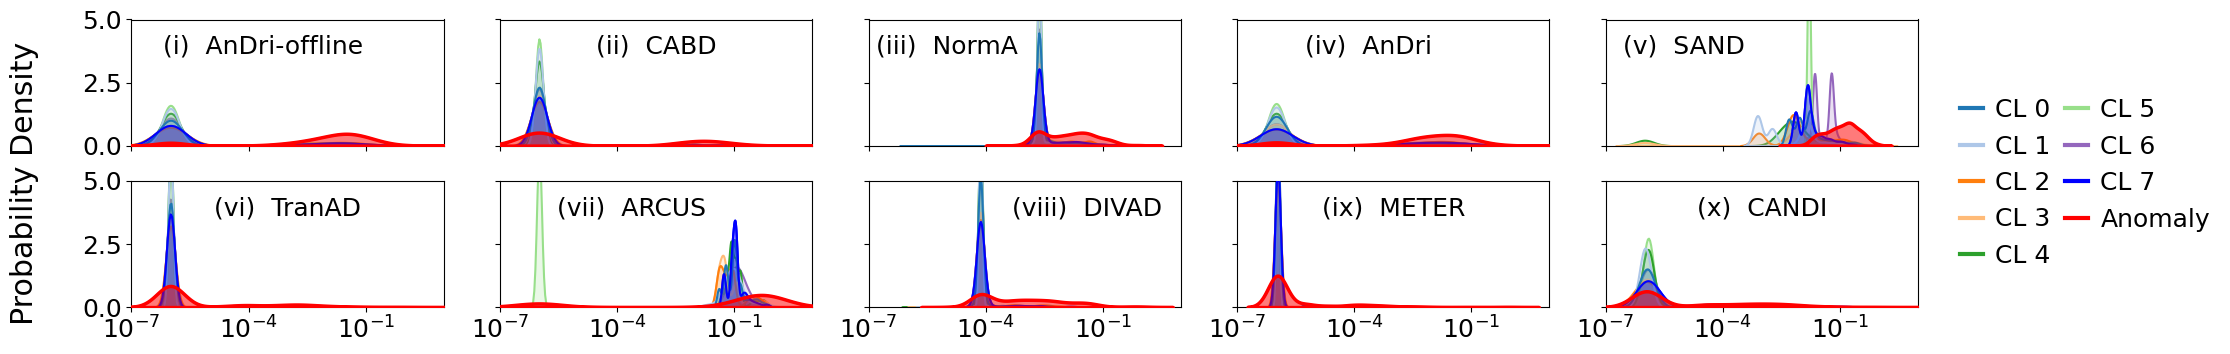

In [87]:
climate_station = 4045695
climate_province = 'SK'
climate_sel_cl = 7
climate_scores, climate_labels, climate_clusters, climate_model, climate_timestamps = saved_plot('climate')
climate_label_table = pd.DataFrame({'datetime': pd.to_datetime(climate_timestamps)})
print(len(climate_labels), 'common timestamps')
draw_kde(NAMES, SimpleNamespace(cl_s=climate_clusters), climate_scores, climate_labels,
         y_max=2, sel_cl=climate_sel_cl, fname=f'{climate_province}_{climate_station}',
         dataset='climate')

#### Climate KDE — selected saved runs (METER/CANDI included)

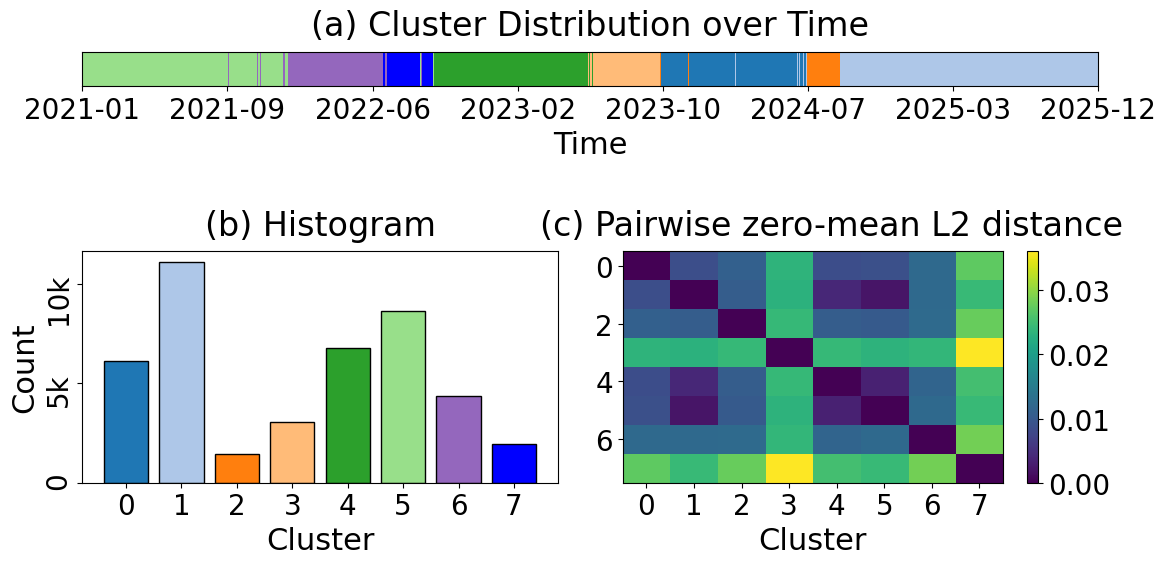

In [88]:
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator

fig = plt.figure(figsize=(12, 6))

gs = fig.add_gridspec(2, 2, height_ratios = [0.15, 1])

ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])

x = climate_model.cl_s

cluster_ids = sorted(np.unique(x.astype(int)))
normal_ids = [cluster_id for cluster_id in cluster_ids if cluster_id != -1]
colors = [color for i, color in enumerate(sns.color_palette('tab20', max(normal_ids, default=-1) + 3)) if i not in (6, 7)]
cluster_colors = {cluster_id: colors[int(cluster_id)] for cluster_id in normal_ids}
if climate_sel_cl in cluster_colors:
    cluster_colors[climate_sel_cl] = 'blue'
if -1 in cluster_ids:
    cluster_colors[-1] = '0.5'
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap([cluster_colors[c] for c in cluster_ids])
norm = BoundaryNorm(np.arange(-0.5, len(cluster_ids) + 0.5), cmap.N)
cluster_positions = np.array([cluster_ids.index(int(cluster_id)) for cluster_id in x])

climate_label_table['datetime'] = pd.to_datetime(climate_label_table['datetime'])
ax0.imshow(
    cluster_positions.reshape(1, -1),
    aspect='auto',
    cmap=cmap,
    norm=norm
)
ax0.set_yticks([])

step = max(1, len(x) // 7)

xticks = np.arange(0, len(x)-1, step)
ax0.set_xticks(xticks)
ax0.set_xticklabels(
    climate_label_table['datetime'].iloc[xticks].dt.strftime('%Y-%m')
)

ax0.set_xlabel('Time', fontsize=22)
ax0.tick_params(axis='x', labelsize=20)


ax0.set_title('(a) Cluster Distribution over Time', fontsize=24, pad=12)

subseqs = []
for i, nm in enumerate(climate_model.NMs):
    subseqs.append(nm.subseq)

counts = pd.Series(x.astype(int)).value_counts().reindex(cluster_ids, fill_value=0).to_numpy()

ax1.bar(range(len(cluster_ids)), counts, color=[cluster_colors[c] for c in cluster_ids], edgecolor='black')

ax1.set_xticks(range(len(cluster_ids)))
ax1.set_xticklabels(['Unassigned' if c == -1 else str(c) for c in cluster_ids])
ax1.set_xlabel('Cluster', fontsize=22)
ax1.yaxis.set_major_locator(MaxNLocator(nbins=4, steps=[1, 2, 5, 10]))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda value, _: '0' if value == 0 else f'{value / 1000:g}k'))
ax1.tick_params(axis='both', labelsize=20)
ax1.tick_params(axis='y', labelrotation=90)
ax1.set_ylabel('Count', fontsize=22)
ax1.set_title('(b) Histogram', fontsize=24, pad=12)

X = np.stack(subseqs)
X_zero_mean = X - X.mean(axis=1, keepdims=True)

dist_mat = squareform(pdist(X_zero_mean, metric='euclidean'))

im2 = ax2.imshow(dist_mat, aspect='auto')

colorbar = fig.colorbar(im2, ax=ax2)
colorbar.ax.tick_params(labelsize=20)
ax2.set_xlabel('Cluster', fontsize=22)
ax2.tick_params(axis='both', labelsize=20)
ax2.set_title("(c) Pairwise zero-mean L2 distance", fontsize=24, pad=12, x=0.55)
ax2.set_xticks(np.arange(len(subseqs)))
ax2.set_xticklabels(np.arange(len(subseqs)))

fig.tight_layout(h_pad=2, w_pad=1.5)
plt.savefig(f'./png/dist_cluster_climate_{climate_station}.pdf', bbox_inches="tight")
plt.show()


## NAB KDE and cluster distribution

2499 saved score points
0 2
1 4
2 4
3 2
4 4
5 4
6 4
7 4
8 4
9 4


/home/parkj182/tmp/ipykernel_187283/489636846.py:54: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


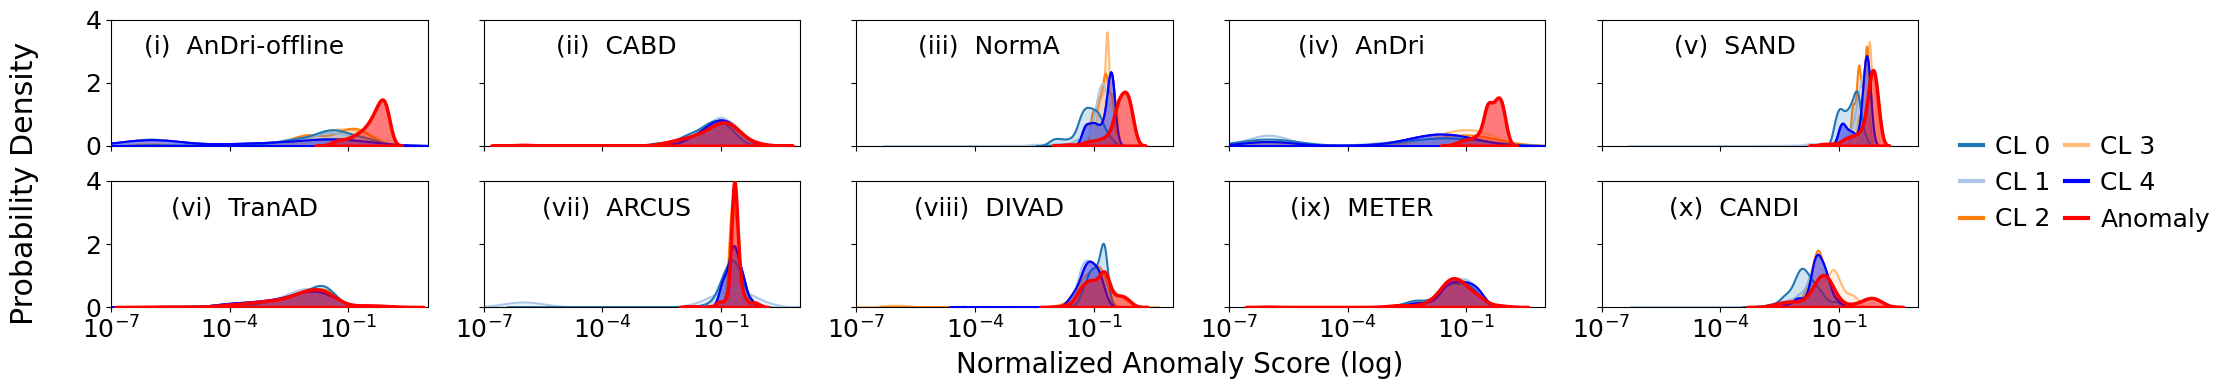

In [89]:
nab_id = 7
sel_cl = 4
nab_scores, nab_labels, nab_clusters, nab_model, _ = saved_plot('nab')
print(len(nab_labels), 'saved score points')
draw_kde(NAMES, SimpleNamespace(cl_s=nab_clusters), nab_scores, nab_labels,
         y_max=2, sel_cl=sel_cl, fname=f'nab_{nab_id}')

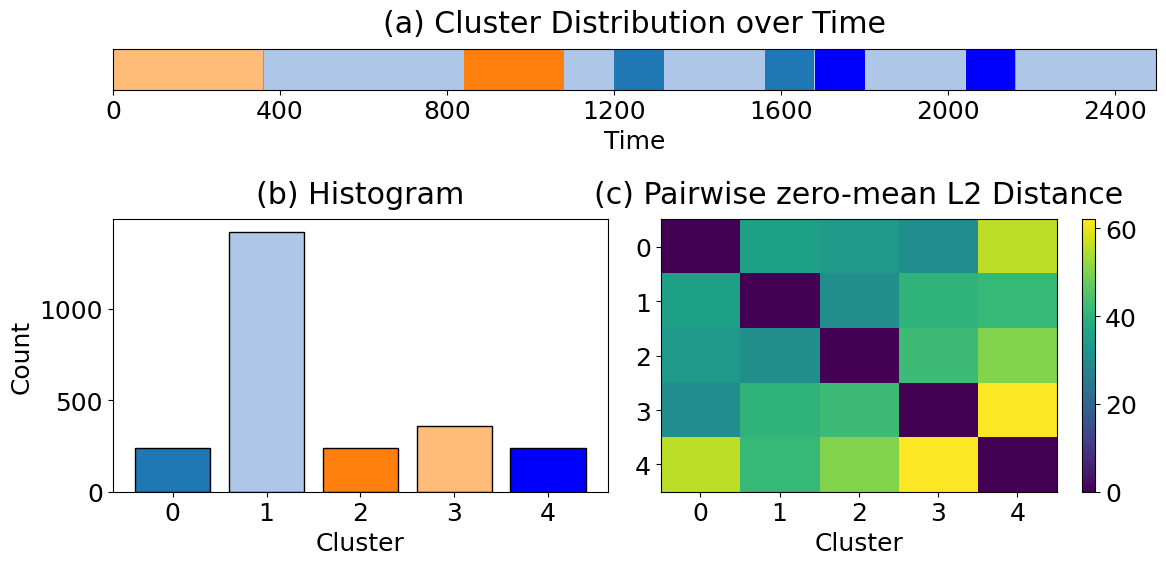

In [90]:
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import BoundaryNorm, ListedColormap
x = np.asarray(nab_model.cl_s, dtype=int)
cluster_ids = sorted(np.unique(x))
normal_ids = [cluster_id for cluster_id in cluster_ids if cluster_id != -1]
colors = [color for i, color in enumerate(
    sns.color_palette('tab20', max(normal_ids, default=-1) + 3)) if i not in (6, 7)]
color_map = {cluster_id: colors[int(cluster_id)] for cluster_id in normal_ids}
if sel_cl in color_map:
    color_map[sel_cl] = 'blue'
if -1 in cluster_ids:
    color_map[-1] = '0.5'

fig = plt.figure(figsize=(12,6))
gs = fig.add_gridspec(2,2,height_ratios=[0.15, 1])

ax0 = fig.add_subplot(gs[0,:]); ax1 = fig.add_subplot(gs[1,0]); ax2 = fig.add_subplot(gs[1,1])
ax0.imshow(np.array([cluster_ids.index(cid) for cid in x]).reshape(1,-1),
    aspect='auto', cmap=ListedColormap([color_map[c] for c in cluster_ids]),
    norm=BoundaryNorm(np.arange(-0.5,len(cluster_ids)+0.5),len(cluster_ids)))
ax0.set_yticks([]); ax0.set_xlabel('Time'); 
xticks = np.arange(0, len(x)-1, 400)
ax0.set_xticks(xticks)
ax0.set_title('(a) Cluster Distribution over Time', pad=12)

counts = pd.Series(x).value_counts().reindex(cluster_ids,fill_value=0)
ax1.bar(range(len(cluster_ids)), counts, color=[color_map[c] for c in cluster_ids], edgecolor='black')
ax1.set_xticks(range(len(cluster_ids))); ax1.set_xticklabels(cluster_ids)
ax1.set_xlabel('Cluster'); ax1.set_ylabel('Count'); ax1.set_title('(b) Histogram', pad=12)
subseqs = np.stack([nm.subseq for nm in nab_model.NMs])
im = ax2.imshow(squareform(pdist(subseqs,metric='euclidean')),aspect='auto')
fig.colorbar(im,ax=ax2); ax2.set_xlabel('Cluster'); ax2.set_title('(c) Pairwise zero-mean L2 Distance', pad=12)
plt.tight_layout()
plt.savefig(f'./png/dist_cluster_nab_{nab_id}.pdf', bbox_inches="tight")

plt.show()


## Cluster ablation — summary


In [91]:
import pandas as pd
from IPython.display import display

results_df = pd.read_csv('results/tested/cluster_ablation_results_df.csv', float_precision='round_trip')
summary_df = results_df.groupby(['dataset', 'clustering'])[['AUC', 'F1']].agg(['mean', 'std', 'count'])
summary_df.columns = ['AUC_mean', 'AUC_std', 'AUC_count', 'F1_mean', 'F1_std', 'F1_count']
summary_df = summary_df.reset_index()
display(summary_df)


,dataset,clustering,AUC_mean,AUC_std,AUC_count,F1_mean,F1_std,F1_count
0,climate,ahc,0.896387,0.017941,30,0.290675,0.047746,30
1,climate,hc,0.781478,0.028350,30,0.254888,0.052974,30
2,climate,kshape,0.786971,0.028424,30,0.262509,0.045759,30
3,nab,ahc,0.807873,0.163107,22,0.578248,0.264274,22
4,nab,hc,0.692284,0.167417,22,0.465797,0.227266,22
5,nab,kshape,0.567970,0.223596,22,0.344916,0.183757,22
6,traffic_2019-01-01,ahc,0.864769,0.048999,30,0.445748,0.046904,30
7,traffic_2019-01-01,hc,0.531845,0.074045,30,0.172138,0.053292,30
8,traffic_2019-01-01,kshape,0.589445,0.168850,30,0.178160,0.124665,30


## Overall AUC and peak-F1


In [92]:
import pandas as pd
from IPython.display import display

overall_auc_f1_df = pd.read_csv('results/tested/overall_auc_f1.csv', float_precision='round_trip')
display(overall_auc_f1_df)


,dataset,method,AUC_mean,AUC_std,peak_f1_mean,peak_f1_std
0,Climate,AnDri-offline,0.90,0.02,0.29,0.05
1,Climate,CABD,0.68,0.02,0.22,0.04
2,Climate,NormA,0.86,0.02,0.28,0.05
3,Climate,AnDri,0.88,0.02,0.29,0.05
4,Climate,SAND,0.84,0.03,0.29,0.04
5,Climate,TranAD,0.68,0.06,0.27,0.05
6,Climate,ARCUS,0.78,0.06,0.23,0.05
7,Climate,DIVAD,0.80,0.06,0.24,0.08
8,Climate,METER,0.64,0.04,0.21,0.04
9,Climate,CANDI,0.68,0.04,0.14,0.03
